In [25]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys
import matplotlib.pyplot as plt
from pathlib import Path
from spatialkfold.clusters import spatial_kfold_clusters


PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

# Get file location stuff
from config.paths import MAIN_DATASET

df = pd.read_csv(MAIN_DATASET)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

gdf = gdf.to_crs("EPSG:3347")

gdf["id"] = range(len(gdf))

In [ ]:
gdf_folds = spatial_kfold_clusters(
    gdf=gdf,
    name="id",
    nfolds=400,
    algorithm="kmeans",
    n_init="auto",
    random_state=42
)

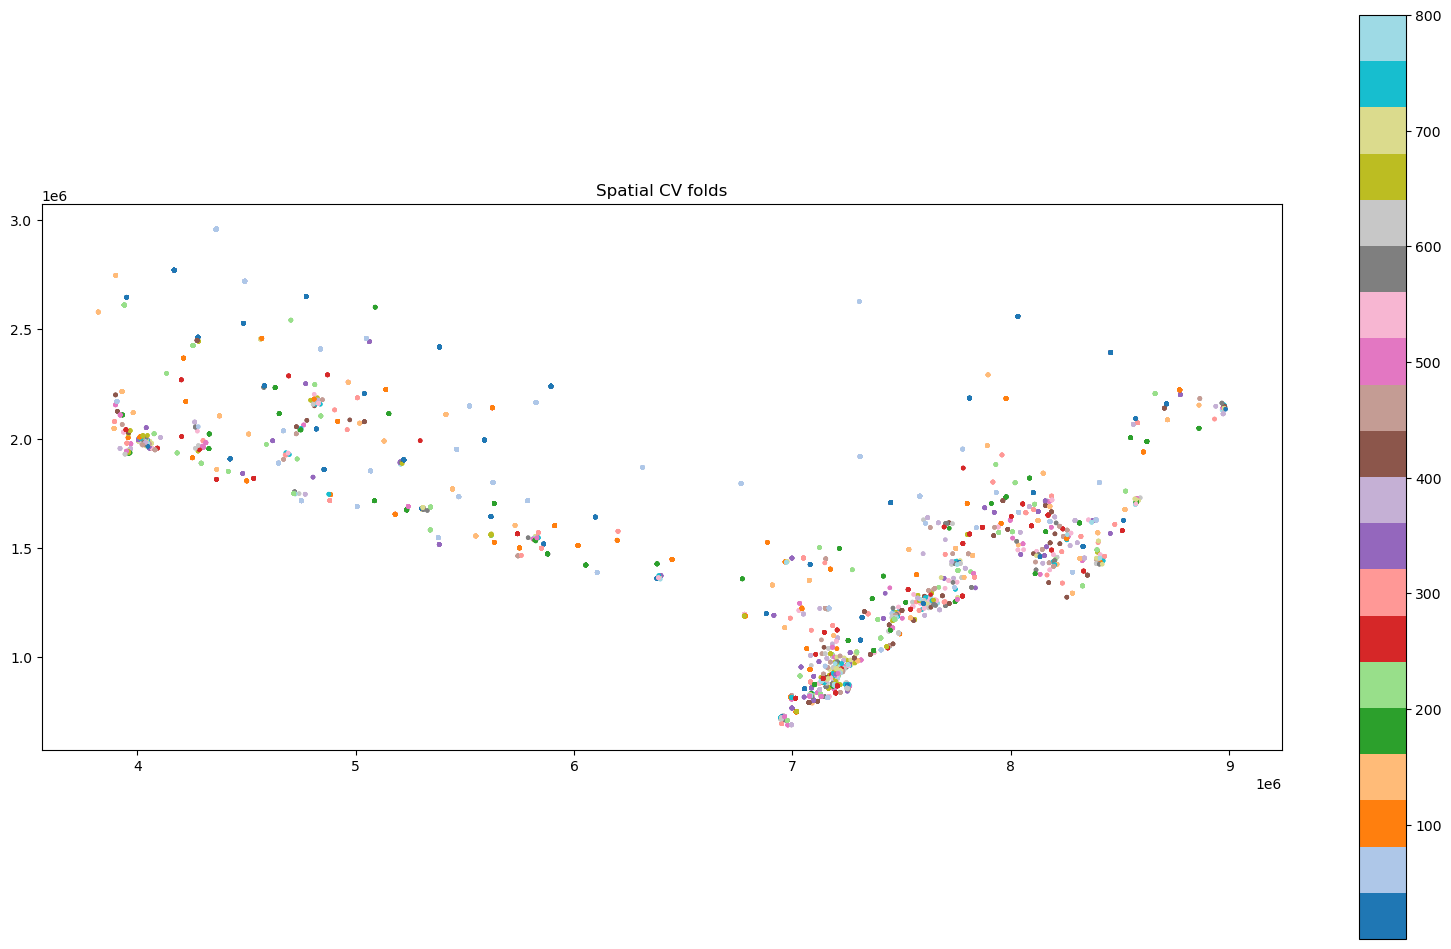

In [27]:

gdf_folds.plot(
    column="folds",
    cmap="tab20",
    markersize=5,
    legend=True,
    figsize=(20,12)
)

plt.title("Spatial CV folds")
plt.show()

In [28]:
centroids_of_clusters = (
    gdf_folds
    .dissolve(by="folds")
    .centroid
    .reset_index()
)

In [29]:
centroids_of_clusters["x"] = centroids_of_clusters.geometry.x
centroids_of_clusters["y"] = centroids_of_clusters.geometry.y

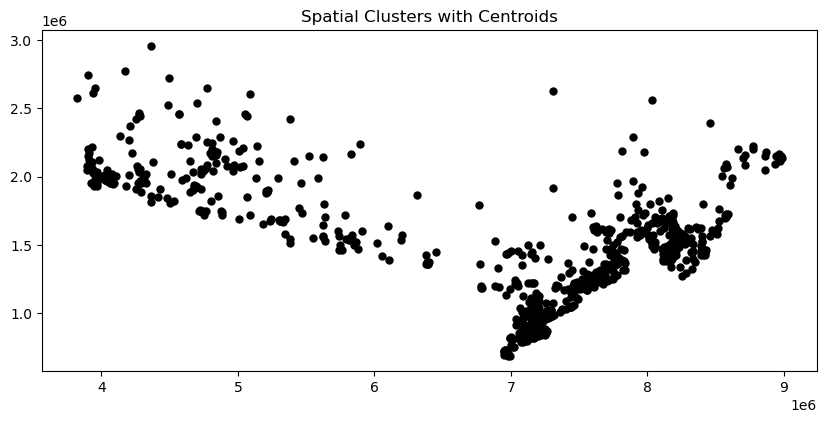

In [30]:
fig, ax = plt.subplots(figsize=(10,6))

gdf_folds.plot(
    column="folds",
    cmap="tab20",
    markersize=3,
    ax=ax,
    alpha=0.6
)

centroids_of_clusters.plot(
    ax=ax,
    color="black",
    markersize=100,
    marker="."
)

plt.title("Spatial Clusters with Centroids")
plt.show()

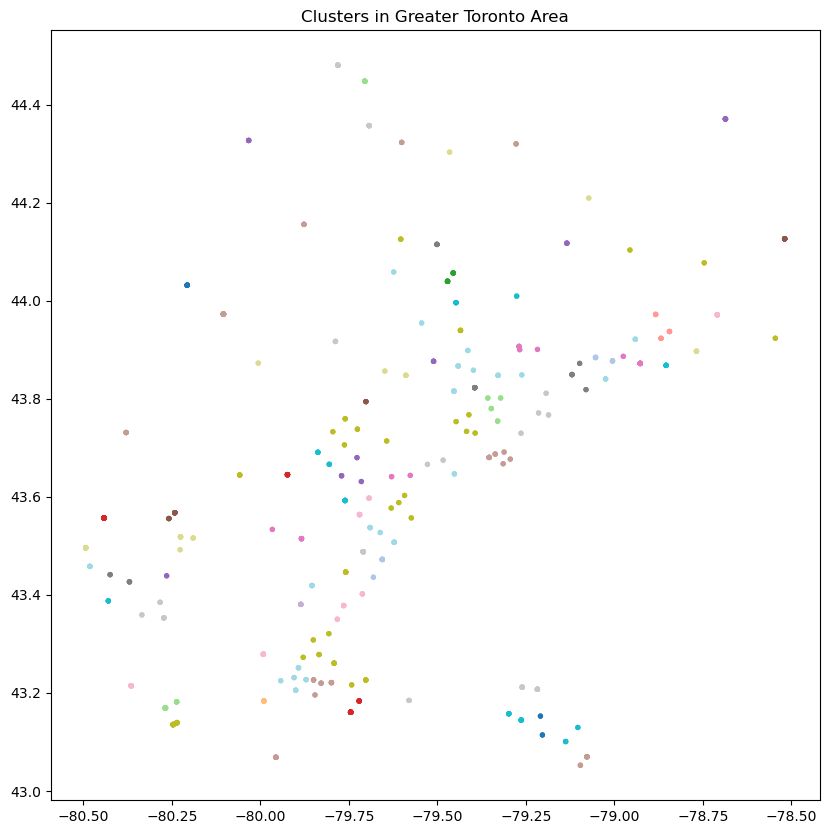

In [31]:
gdf_latlon = gdf_folds.to_crs("EPSG:4326")

toronto_bounds = {
    "lon_min": -80.5,
    "lon_max": -78.5,
    "lat_min": 43.0,
    "lat_max": 44.5
}

gta = gdf_latlon[
    (gdf_latlon.geometry.x > toronto_bounds["lon_min"]) &
    (gdf_latlon.geometry.x < toronto_bounds["lon_max"]) &
    (gdf_latlon.geometry.y > toronto_bounds["lat_min"]) &
    (gdf_latlon.geometry.y < toronto_bounds["lat_max"])
]

fig, ax = plt.subplots(figsize=(10,10))

gta.plot(
    column="folds",
    cmap="tab20",
    markersize=8,
    ax=ax
)

plt.title("Clusters in Greater Toronto Area")

plt.savefig("clusters_toronto.png", dpi=600)
plt.show()

In [32]:
gdf_folds["folds"].value_counts()

folds
35     175
17     143
23     136
69     127
26     127
      ... 
609      2
627      2
541      2
58       2
658      2
Name: count, Length: 800, dtype: int64